## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this second laboratory we will gain some experience working with Transformer models for a variety tasks using (mostly) the Hugging Face Ecosystem. 

In [1]:
# Global Variables
import torch

device = "mps" if torch.backends.mps.is_available() else "cpu"


---
### Exercise 1: Sentiment Analysis (warm up)

In this first exercise we will start from a pre-trained BERT transformer and build up a model able to perform text sentiment analysis. Transformers are complex beasts, so we will build up our pipeline in several explorative and incremental steps.

#### Exercise 1.1: Loading the Dataset Splits
There are a many sentiment analysis datasets, but we will use one of the smallest ones available: the [Cornell Rotten Tomatoes movie review dataset](https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes), which consists of 5,331 positive and 5,331 negative processed sentences from the Rotten Tomatoes movie reviews.

**Your first task**: Load the dataset and figure out what splits are available and how to get them. Spend some time exploring the dataset to see how it is organized. Note that we will be using the [HuggingFace Datasets](https://huggingface.co/docs/datasets/en/index) library for downloading, accessing, splitting, and batching data for training and evaluation.

In [2]:
# Dataset imports.
from datasets import load_dataset, get_dataset_split_names

# Your code here.
splits = get_dataset_split_names("cornell-movie-review-data/rotten_tomatoes")
print(splits)

'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes/resolve/aa13bc287fa6fcab6daf52f0dfb9994269ffea28/rotten_tomatoes.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since cornell-movie-review-data/rotten_tomatoes couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/lapotinacci/.cache/huggingface/datasets/cornell-movie-review-data___rotten_tomatoes/default/0.0.0/aa13bc287fa6fcab6daf52f0dfb9994269ffea28 (last modified on Fri Jun 26 11:50:20 2026).


['train', 'validation', 'test']


In [3]:
ds_dict = {split: load_dataset("cornell-movie-review-data/rotten_tomatoes", split=split) for split in splits}

'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes/resolve/aa13bc287fa6fcab6daf52f0dfb9994269ffea28/rotten_tomatoes.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since cornell-movie-review-data/rotten_tomatoes couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/lapotinacci/.cache/huggingface/datasets/cornell-movie-review-data___rotten_tomatoes/default/0.0.0/aa13bc287fa6fcab6daf52f0dfb9994269ffea28 (last modified on Fri Jun 26 11:50:20 2026).
'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes/resolve/aa13bc287fa6fcab6daf52f0dfb9994269ffea28/rotten_tomatoes.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since cornell-movie-review-data/rotten_tomatoes couldn

In [4]:
import numpy as np

ds_train = ds_dict["train"]
for row in np.random.permutation(len(ds_train))[:5]:
    print(f"Label: {ds_train[row]['label']}, Text: {ds_train[row]['text']}")

Label: 1, Text: worth a look as a curiosity .
Label: 1, Text: it's the filmmakers' post-camp comprehension of what made old-time b movies good-bad that makes eight legged freaks a perfectly entertaining summer diversion .
Label: 0, Text: hit and miss as far as the comedy goes and a big ole' miss in the way of story .
Label: 1, Text: darkly funny and frequently insightful .
Label: 1, Text: mixes likeable personalities , inventive photography and cutting , and wall-to-wall toe-tapping music to paint a picture of a subculture that is at once exhilarating , silly , perverse , hopeful and always fun .



---
### Exercise 1.2: A Pre-trained BERT and Tokenizer

The model we will use is a *very* small BERT transformer called [DistilBERT](https://huggingface.co/distilbert/distilbert-base-uncased) this model was trained (using self-supervised learning) on the same corpus as BERT but using the full BERT base model as a *teacher*.

**Your next task**: Load the DistilBERT model and corresponding tokenizer. Use the tokenizer on a few samples from the dataset and pass the tokens through the model to see what outputs are provided. I suggest you use the [`AutoModel`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html) class (and the `from_pretrained()` method) to load the model and `AutoTokenizer` to load the tokenizer).

In [5]:
# AutoClass imports.
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

In [6]:
tokens_pt = tokenizer.encode("Example sentence for tokenization.", return_tensors="pt", padding=True) #padding inutile in questo caso
tokens = tokenizer.encode("Example sentence for tokenization.")
print(type(tokens))
type(tokens) == type(tokens_pt) 

<class 'list'>


False

**Scomposizione in Subwords:** il tokenizer di BERT utilizza l'algoritmo **WordPiece**, che scompone le parole rare o complesse in sotto-parole (es. *Nuotatore* $\rightarrow$ `["Nuota", "##tore"]`).Questo approccio evita l'esplosione delle dimensioni del vocabolario, mantenendolo compatto.

Come si può vedere **di default restituisce una lista non un tensore**, tuttavia si può specificare la natura della lista durante la chiamata della funzione.

In [7]:
batch = tokenizer(["Example sentence for tokenization.", "Another example sentence."], return_tensors="pt", padding=True)
print(batch)

{'input_ids': tensor([[  101,  2742,  6251,  2005, 19204,  3989,  1012,   102],
        [  101,  2178,  2742,  6251,  1012,   102,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 0, 0]])}


**Il padding aiuta a uniformare la lunghezza** delle stringhe in input all'interno del batch, essendo la seconda frase più corta in questo caso vengono aggiunti degli zeri per raggiungere la lunghezza della frasse più lunga. Da notare anche la **lunghezza dell'_attention mask_** la quale è la medesima ma come si può osservare i valori dell'attention sono 0 in corrisponedenza di quelli in cui lo 0 di padding è stato aggiunto.

In [8]:
model = AutoModel.from_pretrained("distilbert/distilbert-base-uncased")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Come funziona BERT con le parole complesse?

Prendiamo l'esempio della parola "Nuotatore" utilizzata per spiegare il funzionamento del tokenizer.
**Allineamento Dinamico:** Il modello non ha bisogno di memorizzare la parola intera in addestramento. Grazie al meccanismo di **Self-Attention**, i vettori di radice (`Nuota`) e suffisso (`##tore`) vengono allineati e fusi strato dopo strato.

**Risultato:** BERT genera "al volo" l'embedding della parola complessa, posizionandolo nello spazio semantico corretto sia per significato (nuoto) che per sintassi (sostantivo).

Il modello ha anche 2 tipologie di embeddings:
- il primo riguarda le parole note al transformer (il vocabolario), detto anche _WordEmbedding_ in cui ogni parola viene mappata ad un vettore di dimensione 768.
- il secondo tiene conto della posizione, il _PositionalEmbedding (512x768)_ in questo caso il vettore serve a **mappare la posizione nella frase dei vari token** per introdurre la posizione dei vari token in input.

Le due tipologie di Embeddings vengono poi sommate insieme per ottenere l'input al modello vero e proprio.

In [9]:
#Piccolo esperimento 

Phrase_1 = "Which city is the capital of France?"
phrase_2 = "The capital of France is Paris."

tokenized_phrases = tokenizer(Phrase_1, phrase_2, return_tensors="pt", padding=True)

tokenized_phrases.to(device)
model.to(device)

with torch.no_grad():
     model_output = model.forward(tokenized_phrases["input_ids"],
                             attention_mask=tokenized_phrases["attention_mask"]).last_hidden_state

print(f"Shape of model output: {model_output.shape}")
print(f"Model output for the first token of the first phrase: {model_output[0][0]}")

embeddings_vocab = model.embeddings.word_embeddings.weight.data
for i in range(len(model_output[0])):
    target_embedding = model_output[0, i, :] 
    similarities = torch.matmul(embeddings_vocab, target_embedding)
    most_similar_token_id = torch.argmax(similarities).item()
    predicted_token = tokenizer.convert_ids_to_tokens(most_similar_token_id)
    print(f"Token {i}: ID del token: {most_similar_token_id}, Token testuale ricostruito: {predicted_token}")

Shape of model output: torch.Size([1, 18, 768])
Model output for the first token of the first phrase: tensor([-4.1983e-02, -7.1013e-02,  6.7466e-02, -5.6701e-02, -2.3404e-01,
        -5.0870e-02,  1.5727e-01,  5.3942e-01, -3.9490e-01, -2.5209e-01,
        -2.4199e-02, -1.9331e-01, -1.7624e-01,  2.2888e-01,  9.6133e-02,
         1.3398e-01, -1.7401e-01,  3.4628e-01,  1.3058e-01, -3.9329e-02,
        -5.3515e-02, -8.2306e-02,  1.0358e-01, -1.0898e-02,  9.7436e-02,
        -1.1302e-01,  1.2228e-02, -1.3618e-03,  1.3944e-01, -9.6037e-02,
         1.1337e-01,  1.4649e-01, -2.1320e-01, -1.5620e-01,  1.3660e-01,
        -1.0712e-01,  1.4628e-01, -3.5282e-02,  1.7216e-01,  1.3071e-01,
        -5.5678e-02,  7.6223e-03,  1.2651e-01,  1.2188e-01, -5.2778e-02,
        -1.8149e-01, -2.2705e+00,  9.4291e-02, -4.1622e-02, -1.1364e-02,
        -6.6725e-02, -3.6036e-03,  5.9326e-02,  5.5112e-01,  2.8651e-01,
         3.2456e-01, -4.6845e-01,  3.1556e-01, -1.7828e-01, -2.7823e-02,
         2.2735e-01,  

Qui mi sono divertito un pò andando ad utilizzare quella che dovrebbe essere l'altra modalità di BERT, ovvero l'analisi di verità di una frase. BERT infatti può avere come input 2 frasi distinte e riconoscerne il valore di verità se nella seconda viene fatta un'affermazione con rispetto alla prima. Nell'esempio chiedo se la risposta alla domanda sulla capitale della Francia sia effettivamente corretta.

Ho scoperto dopo che a DistilBERT è stata rimossa questa "capacità" per abbattese il peso del modello e aumentare la velocità dell'inferenza.

In [10]:
model_train = ds_dict["train"]
model_test = ds_dict["test"]

In [11]:
for i in range(2):
     print(f"lunghezza frase numero {i+1}: {len(model_train[i]["text"])}")
batch = tokenizer(model_train["text"][:2], return_tensors="pt", padding=True)
batch.to(device)

lunghezza frase numero 1: 177
lunghezza frase numero 2: 226


{'input_ids': tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102,     0,     0,     0,
             0,     0],
        [  101,  1996,  9882,  2135,  9603, 13633,  1997,  1000,  1996,  2935,
          1997,  1996,  7635,  1000, 11544,  2003,  2061,  4121,  2008,  1037,
          5930,  1997,  2616,  3685, 23613,  6235,  2522,  1011,  3213,  1013,
          2472,  2848,  4027,  1005,  1055,  4423,  4432,  1997,  1046,  1012,
          1054,  1012,  1054,  1012, 23602,  1005,  1055,  2690,  1011,  3011,
          1012,   102]], device='mps:0'), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0

In [12]:
preds = model.forward(batch["input_ids"], attention_mask=batch["attention_mask"]).last_hidden_state
preds_no_attention_mask = model.forward(batch["input_ids"]).last_hidden_state

Shape of predictions with attention mask: torch.Size([2, 52, 768])
Shape of predictions without attention mask: torch.Size([2, 52, 768])


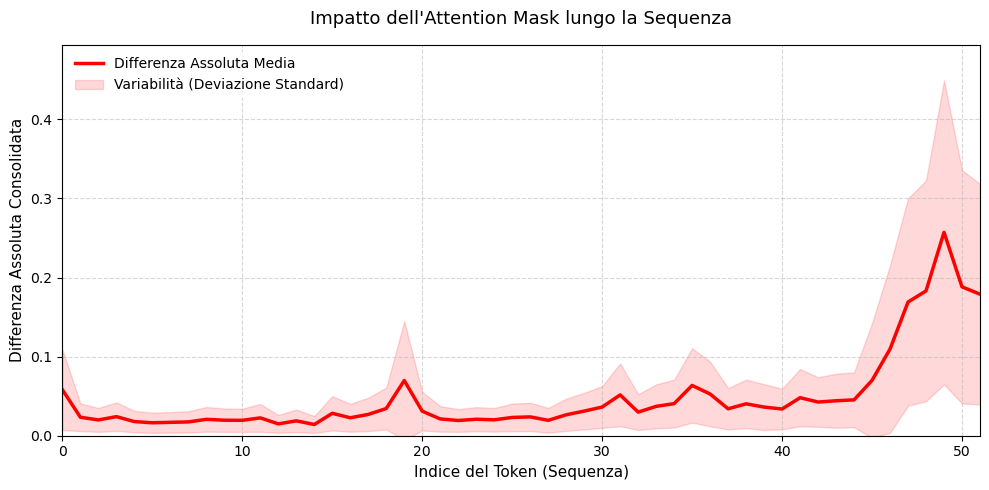

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Shape of predictions with attention mask: {preds.shape}")
print(f"Shape of predictions without attention mask: {preds_no_attention_mask.shape}")

diff = np.abs(preds[0].detach().cpu().numpy() - preds_no_attention_mask[0].detach().cpu().numpy())

mean_diff_per_token = np.mean(diff, axis=1)
std_diff_per_token = np.std(diff, axis=1)

plt.figure(figsize=(10, 5))

# Disegniamo la linea della media
plt.plot(mean_diff_per_token, color='red', label='Differenza Assoluta Media', linewidth=2.5)

# Disegniamo l'area di variabilità (deviazione standard)
plt.fill_between(range(len(mean_diff_per_token)), 
                 mean_diff_per_token - std_diff_per_token, 
                 mean_diff_per_token + std_diff_per_token, 
                 color='red', alpha=0.15, label='Variabilità (Deviazione Standard)')

plt.xlim(0, len(mean_diff_per_token) - 1)
plt.ylim(0, np.max(mean_diff_per_token + std_diff_per_token) * 1.1) 

# Dettagli estetici
plt.title("Impatto dell'Attention Mask lungo la Sequenza", fontsize=13, pad=15)
plt.xlabel("Indice del Token (Sequenza)", fontsize=11)
plt.ylabel("Differenza Assoluta Consolidata", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout() # Ottimizza gli spazi dei margini
plt.show()

Come si può vedere i **risultati sono diversi**, il che dimostra l'importanza dell'attenzione nel modello. Infatti quando il modello calcola l'attenzione, esso fa una combinazione lineare dei token che gli vengono forniti in ingresso; _se non venisse fornita_ la maschera per l'attenzione  tutti i token verrebbero trattati allo stesso modo **inclusi** quelli di padding. I token di padding vengono ignorati quando si fornisce la maschera per l'attenzione. 
Ricordiamo che l'attenizone è calcolata nel seguente modo $$\text{Attention}(Q,K,V)=\text{Softmax}\left(\frac{QK^T}{\sqrt{d_k}}+M\right)V$$ dove M è la maschera per l'attenzione, in questo caso possiamo considerare i valori inerenti ai token di padding (corrispondenti agli 0 della maschera) come `-inf`.

NOTA: Ho usato _Gemini 3.5 flash_ per generare il codice per la visualizzazione della differenza.


---
### Exercise 1.3: A Stable Baseline

In this exercise I want you to:
1. Use DistilBERT as a *feature extractor* to extract representations of the text strings from the dataset splits;
2. Train a classifier (your choice, by an SVM from Scikit-learn is an easy choice).
3. Evaluate performance on the validation and test splits.

These results are our *stable baseline* -- the **starting** point on which we will (hopefully) improve in the next exercise.

**Hint**: There are a number of ways to implement the feature extractor, but probably the best is to use a [feature extraction `pipeline`](https://huggingface.co/tasks/feature-extraction). You will need to interpret the output of the pipeline and extract only the `[CLS]` token from the *last* transformer layer. *How can you figure out which output that is?*

In [14]:
from transformers import pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Your code here.
extractor = pipeline("feature-extraction", model=model, tokenizer=tokenizer, device=device, batch_size=16)
feats = extractor(list(model_train["text"]), return_tensors="pt")


In [15]:
feats = torch.vstack([feat[0][0] for feat in feats])
feats.shape

torch.Size([8530, 768])

In [16]:
TestFeats = extractor(list(model_test['text']), return_tensors="pt")

In [17]:
TestFeats = torch.vstack([feat[0][0] for feat in TestFeats])
TestFeats.shape

torch.Size([1066, 768])

In [18]:
svm = LinearSVC()
svm.fit(feats, model_train["label"])
preds = svm.predict(TestFeats)
print(classification_report(model_test["label"], preds))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80       533
           1       0.81      0.78      0.80       533

    accuracy                           0.80      1066
   macro avg       0.80      0.80      0.80      1066
weighted avg       0.80      0.80      0.80      1066



La SVM adddestrata sugli output prodotti dal modello BERT per la classificazione del sentiment ha un'**accuratezza del 79%**.

---
---
## Exercise 2: Fine-tuning DistilBERT

In this exercise we will fine-tune the DistilBERT model to (hopefully) improve sentiment analysis performance.


---
### Exercise 2.1: Token Preprocessing

The first thing we need to do is *tokenize* our dataset splits -- we don't want to re-tokenize our inputs for every batch! Our current datasets return a dictionary with *strings*, but we want *input token ids* (i.e. the output of the tokenizer). This is easy enough to do by hand, but the Hugging Face `Dataset` class provides convenient, efficient, and *lazy* methods. See the documentation for [`Dataset.map`](https://huggingface.co/docs/datasets/v3.5.0/en/package_reference/main_classes#datasets.Dataset.map).

**Tip**: Verify that your new datasets are returning for every element: `text`, `label`, `intput_ids`, and `attention_mask`.

In [1]:
# Dataset imports.
from datasets import load_dataset, get_dataset_split_names
import numpy as np

# Your code here.
splits = get_dataset_split_names("cornell-movie-review-data/rotten_tomatoes")
print(splits)

dataset = {split: load_dataset("cornell-movie-review-data/rotten_tomatoes", split=split) for split in splits}

model_train = dataset["train"]
model_val = dataset["validation"]
model_test = dataset["test"]

['train', 'validation', 'test']


In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

exp=tokenizer(model_train[0]['text'], return_tensors="pt", padding=True)
exp_2 = tokenizer(model_train[1]['text'], return_tensors="pt", padding=True)
print(exp['attention_mask'].shape[-1] == exp_2['attention_mask'].shape[-1])

False


Come possiamo vedere utilizzando dei vettori pre-processati in modo indipendente dimensioni differenti, per mostrare la differenza ho considerato la lunghezza dell'`attention_mask` poiché sono elaborati in modo indipendente gli input essa ha dimensione pari alla lunghezza della frase e valore sempre 1. Dobbiamo dunque correggere il comportamento andando ad uniformare la dimensione dell'input.

In [3]:
tokens = tokenizer(model_train[:2]['text'], return_tensors="pt", padding = 'max_length', max_length=512)
print(tokens['attention_mask'].shape)

torch.Size([2, 512])


Il valore 512 è stato scelto per uniformare tutte le frasi in ingresso alla stessa lunghezza degli elementi della matrice del `PositionalEmbedding`.

In [4]:
# Your code here.
def preprocess(examples):
    return tokenizer(examples["text"], return_tensors="pt", padding = 'max_length', max_length=512, truncation=True)

tokenized_train = model_train.map(preprocess, batched=True)
tokenized_val = model_val.map(preprocess, batched=True)
tokenized_test = model_test.map(preprocess, batched=True)

tokenized_train.set_format("pt", columns=["input_ids"], output_all_columns=True)
tokenized_val.set_format("pt", columns=["input_ids"], output_all_columns=True)
tokenized_test.set_format("pt", columns=["input_ids"], output_all_columns=True)
# La tokenizzazione restituisce una lista di token per ogni frase, quindi è necessario specificare che vogliamo restituire un tensore PyTorch. 
# Inoltre, output_all_columns=True ci permette di mantenere tutte le altre colonne del dataset, come "label", in modo da poterle utilizzare successivamente.

In [5]:
tokenized_train

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 8530
})


---
### Exercise 2.2: Setting up the Model to be Fine-tuned

In this exercise we need to prepare the base Distilbert model for fine-tuning for a *sequence classification task*. This means, at the very least, appending a new, randomly-initialized classification head connected to the `[CLS]` token of the last transformer layer. Luckily, HuggingFace already provides an `AutoModel` for just this type of instantiation: [`AutoModelForSequenceClassification`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html#automodelforsequenceclassification). You will want you instantiate one of these for fine-tuning.

In [6]:
from transformers import AutoModelForSequenceClassification
cls_model = AutoModelForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased", num_labels=2)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


La differenza tra `AutoModel` e `AutoModelForSequenceClassification` è l'output restituito dal modello istanziato dalla classe.
- Nel primo caso ritorna la matrice completa del _last-hidden-state_.
- Nel secondo caso invece restituisce solo l'embedding appartenente al token $[\text{CLS}]$.


---
### Exercise 2.3: Fine-tuning DistilBERT

Finally. In this exercise you should use a HuggingFace [`Trainer`](https://huggingface.co/docs/transformers/main/en/trainer) to fine-tune your model on the Rotten Tomatoes training split. Setting up the trainer will involve (at least):


1. Instantiating a [`DataCollatorWithPadding`](https://huggingface.co/docs/transformers/en/main_classes/data_collator) object which is what *actually* does your batch construction (by padding all sequences to the same length).
2. Writing an *evaluation function* that will measure the classification accuracy. This function takes a single argument which is a tuple containing `(logits, labels)` which you should use to compute classification accuracy (and maybe other metrics like F1 score, precision, recall) and return a `dict` with these metrics.  
3. Instantiating a [`TrainingArguments`](https://huggingface.co/docs/transformers/v4.51.1/en/main_classes/trainer#transformers.TrainingArguments) object using some reasonable defaults.
4. Instantiating a `Trainer` object using your train and validation splits, you data collator, and function to compute performance metrics.
5. Calling `trainer.train()`, waiting, waiting some more, and then calling `trainer.evaluate()` to see how it did.

**Tip**: When prototyping this laboratory I discovered the HuggingFace [Evaluate library](https://huggingface.co/docs/evaluate/en/index) which provides evaluation metrics. However I found it to have insufferable layers of abstraction and getting actual metrics computed. I suggest just using the Scikit-learn metrics...

In [7]:
randomized_tokenized_train = tokenized_train.shuffle(seed=42)
randomized_tokenized_val = tokenized_val.shuffle(seed=123)
randomized_tokenized_test = tokenized_test.shuffle(seed=1066)

Ho utilizzato 3 seed distinti per assicurarmi l'indipendenza delle mescolate

In [8]:
from sklearn.metrics import accuracy_score, f1_score

def output_eval(eval_pred):
     logits, labels = eval_pred
     predictions = np.argmax(logits, axis=-1)
     accuracy = accuracy_score(labels, predictions)
     f1 = f1_score(labels, predictions, average='weighted')
     return {"accuracy": accuracy, "f1": f1}

In [9]:
import os 

if os.path.exists("./distilbert_finetuned"):
     tokenizer = AutoTokenizer.from_pretrained("./distilbert_finetuned")
     cls_model = AutoModelForSequenceClassification.from_pretrained("./distilbert_finetuned")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

training_args = TrainingArguments(
    output_dir="./checkpoint_distilbert",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=8,
    weight_decay=0.02,
    lr_scheduler_type="cosine",
    warmup_steps = 10,
    eval_strategy="epoch",                
    save_strategy="epoch",
    load_best_model_at_end=True,
    dataloader_pin_memory=False,
    dataloader_num_workers=2,
    metric_for_best_model="accuracy",
    dataloader_persistent_workers=True,
)

trainer = Trainer(
    model=cls_model,
    args=training_args,
    train_dataset=randomized_tokenized_train, 
    eval_dataset=randomized_tokenized_val,
    data_collator=data_collator,
    compute_metrics=output_eval,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


In [11]:
if not os.path.exists("./distilbert_finetuned"):
     trainer.train()
     trainer.save_model("./distilbert_finetuned")

In [12]:
predictions_output = trainer.predict(randomized_tokenized_test) # type: ignore

In [31]:
from sklearn.metrics import classification_report

preds = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

print("=" * 60)
print("             REPORT DI CLASSIFICAZIONE          ")
print("=" * 60)
print(classification_report(true_labels, preds, target_names=['Negativo (0)', 'Positivo (1)'])) # type: ignore
print("=" * 60)

             REPORT DI CLASSIFICAZIONE          
              precision    recall  f1-score   support

Negativo (0)       0.82      0.88      0.85       533
Positivo (1)       0.87      0.81      0.84       533

    accuracy                           0.85      1066
   macro avg       0.85      0.85      0.85      1066
weighted avg       0.85      0.85      0.85      1066



Come possiamo osservare rispetto ai risultati della `SVM` c'è un miglioramento di circa il $6\%$ per la **misura di accuratezza**, osserviamo come nel caso del _fine-tuning_ le misure di f1-score e accuracy siano identiche. Questo non è un caso ma è dovuto al fatto che **il dataset di rotten tomatoes è perfettamente bilanciato** in ogni suo split con circa 533 casi positivi e 533 negativi che compongono il dataset di test.

NOTA: Come si può notare ho utilizzato gemini 3.5 flash per migliorare la leggibilità del report si scikit learn.


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! Or if you want to propose something else as a third exercise, reach out to me on the Discord!


---
### Exercise 3.1: Efficient Fine-tuning for Sentiment Analysis

In Exercise 2 we fine-tuned the *entire* Distilbert model on Rotten Tomatoes. This is expensive, even for a small model. Find an *efficient* way to fine-tune Distilbert on the Rotten Tomatoes dataset (or some other dataset).

**Hint**: You could check out the [HuggingFace PEFT library](https://huggingface.co/docs/peft/en/index) for some state-of-the-art approaches that should "just work". How else might you go about making fine-tuning more efficient without having to change your training pipeline from above?

**Why choose this exercise?** PEFT techniques -- especially LoRA are the methods of choice for adapting models to new tasks.

In [2]:
# Dataset imports.
from datasets import load_dataset, get_dataset_split_names
import numpy as np
from transformers import AutoTokenizer

# Your code here.
splits = get_dataset_split_names("cornell-movie-review-data/rotten_tomatoes")
print(splits)

dataset = {split: load_dataset("cornell-movie-review-data/rotten_tomatoes", split=split) for split in splits}

model_train = dataset["train"]
model_val = dataset["validation"]
model_test = dataset["test"]

tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

# Your code here.
def preprocess(examples):
    return tokenizer(examples["text"], return_tensors="pt", padding = 'max_length', max_length=512, truncation=True)

tokenized_train = model_train.map(preprocess, batched=True)
tokenized_val = model_val.map(preprocess, batched=True)
tokenized_test = model_test.map(preprocess, batched=True)

tokenized_train.set_format("pt", columns=["input_ids"], output_all_columns=True)
tokenized_val.set_format("pt", columns=["input_ids"], output_all_columns=True)
tokenized_test.set_format("pt", columns=["input_ids"], output_all_columns=True)

['train', 'validation', 'test']


In [3]:
# Your code here.
from peft import LoraConfig, get_peft_model, TaskType

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=8,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],
    exclude_modules=["classifier"],
)

In [4]:
from transformers import AutoModelForSequenceClassification
cls_model = AutoModelForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased", num_labels=2)


#print(cls_model)

model_LoRA = get_peft_model(cls_model, peft_config)
print(model_LoRA.print_trainable_parameters())


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925
None


In [5]:
randomized_tokenized_train = tokenized_train.shuffle(seed=42)
randomized_tokenized_val = tokenized_val.shuffle(seed=123)
randomized_tokenized_test = tokenized_test.shuffle(seed=1066)

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding, EarlyStoppingCallback

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

training_args = TrainingArguments(
    output_dir="./checkpoint_distilbert_LoRA",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    weight_decay=0.02,
    lr_scheduler_type="cosine",
    warmup_steps = 10,
    eval_strategy="epoch",                
    save_strategy="epoch",
    load_best_model_at_end=True,
    dataloader_pin_memory=False,
    dataloader_num_workers=2,
    metric_for_best_model="accuracy",
    dataloader_persistent_workers=True,
)

trainer = Trainer(
    model=model_LoRA,
    args=training_args,
    train_dataset=randomized_tokenized_train, 
    eval_dataset=randomized_tokenized_val,
    data_collator=data_collator,
    compute_metrics=output_eval,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


In [11]:
trainer.train()
trainer.save_model("./distilbert_finetuned_LoRA")

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.575858,0.420009,0.815197,0.815111
2,0.417601,0.391863,0.823640,0.823460
3,0.398983,0.382302,0.832083,0.832017
4,0.386989,0.375803,0.834897,0.834868
5,0.371071,0.374819,0.833959,0.833957
6,0.375671,0.371997,0.833021,0.832992


In [12]:
predictions_output = trainer.predict(randomized_tokenized_test) # type: ignore


In [13]:
from sklearn.metrics import classification_report

preds = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

print("=" * 60)
print("             REPORT DI CLASSIFICAZIONE          ")
print("=" * 60)
print(classification_report(true_labels, preds, target_names=['Negativo (0)', 'Positivo (1)'])) # type: ignore
print("=" * 60)

             REPORT DI CLASSIFICAZIONE          
              precision    recall  f1-score   support

Negativo (0)       0.83      0.84      0.83       533
Positivo (1)       0.84      0.82      0.83       533

    accuracy                           0.83      1066
   macro avg       0.83      0.83      0.83      1066
weighted avg       0.83      0.83      0.83      1066




---
### Exercise 3.2: Fine-tuning a CLIP Model (harder)

Use a (small) CLIP model like [`openai/clip-vit-base-patch16`](https://huggingface.co/openai/clip-vit-base-patch16) and evaluate its zero-shot performance on a small image classification dataset like ImageNette or TinyImageNet. Fine-tune (using a parameter-efficient method!) the CLIP model to see how much improvement you can squeeze out of it.

**Note**: There are several ways to adapt the CLIP model; you could fine-tune the image encoder, the text encoder, or both. Or, you could experiment with prompt learning.

**Tip**: CLIP probably already works very well on ImageNet and ImageNet-like images. For extra fun, look for an image classification dataset with different image types (e.g. *sketches*).

**Why choose this exercise?** CLIP is probably the most widely used Vision-Language Model, and adapting it is a useful skill to master.

In [33]:
# Your code here.


---
### Exercise 3.3: A Text-to-image Retrieval System (hard, but not *too* hard)

Implement a simple text-to-image retrieval system with a simple user interface --- using, for example, [gradio](https://www.gradio.app/), or [Marimo](https://marimo.io/), or [Shiny](https://shiny.posit.co/). Your application should *index* (e.g. compute visual descriptors for) a small dataset of images like [Flickr8k](https://huggingface.co/datasets/jxie/flickr8k). It should provide a user interface with which a user can enter a short text prompt (e.g. "a photo of dogs playing in the snow") and then display the top-10 matching images from the indexed dataset.

Note that there is no following code block with "Your code here" for this exercise. You will definitely want to implement this outside of a Jupyter Notebook.

**Hint**: The **CLIP** model is practically *made* for just such an application.

**Why choose this exercise?** Well, this is a course on Deep Learning *Applications*, and this is your chance to *build* one!

---
---